# **Imports & Downloading**

In [1]:
!apt-get install ffmpeg
!apt-get install ffprobe

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package ffprobe


In [2]:
!pip install ffmpeg ffprobe

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=f3111a90a79936ff1a7c7c8f4d071f26ce98eed3a44391ce318ea6f323c56fd9
  Stored in directory: /root/.cache/pip/wheels/26/21/0c/c26e09dff860a9071683e279445262346e008a9a1d2142c4ad
  Created wheel for ffprobe: filename=ffprobe-0.5-py3-none-any.whl size=3408 sha256=e2bee6f9608cfd35a24f1e955555afde44c6175c54c388cc8b5c406fe18805e4
  Stored in directory: /root/.cache/pip/wheels/69/73/0b/d157d05e5a665857ca8aaf2ab607f09fcb60e361467d2574fa
Successfully built ffmpeg ffprobe


In [3]:
import numpy as np
import pandas as pd
import imageio
import os
import warnings
import glob
import time
import random
from tqdm import tqdm
from argparse import ArgumentParser
from skimage import img_as_ubyte
from skimage.transform import resize
warnings.filterwarnings("ignore")
import cv2
import subprocess

In [4]:
!apt-get update -qq
!apt-get install -y aria2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 38 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc-ares2 amd64 1.18.1-1ubuntu0.22.04.3 [45.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libaria2-0 amd64 1.36.0-1 [1,086 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 aria2 amd64 1.36.0-1 [381 kB]
Fetched 1,513 kB in 1s (1,274 kB/s)
Selecting previously unselected package libc-ares2:amd6

In [5]:
torrent_url = "https://academictorrents.com/download/843b5adb0358124d388c4e9836654c246b988ff4.torrent"
!aria2c --seed-time=0 "{torrent_url}"


09/26 08:43:15 [NOTICE] Downloading 1 item(s)

09/26 08:43:16 [NOTICE] Download complete: /content/CelebV-HQ-843b5adb0358124d388c4e9836654c246b988ff4.torrent

09/26 08:43:16 [ERROR] Exception caught while loading DHT routing table from /root/.cache/aria2/dht.dat
Exception: [DHTRoutingTableDeserializer.cc:82] errorCode=1 Failed to load DHT routing table from /root/.cache/aria2/dht.dat

09/26 08:43:16 [NOTICE] IPv4 DHT: listening on UDP port 6963

09/26 08:43:16 [NOTICE] IPv4 BitTorrent: listening on TCP port 6893

09/26 08:43:16 [ERROR] IPv6 BitTorrent: failed to bind TCP port 6893
Exception: [SocketCore.cc:312] errorCode=1 Failed to bind a socket, cause: Name or service not known
 *** Download Progress Summary as of Fri Sep 26 08:44:16 2025 *** 
=
[#9634b5 574MiB/38GiB(1%) CN:7 SD:4 DL:17MiB ETA:36m55s]
FILE: /content/CelebV-HQ/celebvhq.tar.gz (2more)
-

 *** Download Progress Summary as of Fri Sep 26 08:45:16 2025 *** 
=
[#9634b5 1.5GiB/38GiB(3%) CN:9 SD:4 DL:14MiB ETA:43m4s]
FILE: /

# **Data Collection**

In [123]:
# import shutil
# shutil.rmtree('/content/sample_raw')
# shutil.rmtree('/content/clean_vids')
# shutil.rmtree('/content/clean_audios')
# shutil.rmtree('/content/logs')
# %rm -f /content/clips_list.json
# %rm -f /content/unique_clips.json
# %rm -f /content/failures_valid.txt
# %rm -f /content/mapping_valid.csv
# %rm -f /content/clips_with_audio.json
# %rm -f /content/failures_audio_check.txt
# %rm -f /content/final_dataset_metadata.csv

In [128]:
import json
import random
import sys
from pathlib import Path

# --- CONFIGURATION ---
JSON_PATH = Path('/content/CelebV-HQ/celebvhq_info.json')
# The final number of videos you want in your dataset
N_TARGET = 2600
# The file that will be used by all downstream scripts
OUT_JSON = Path('clips_list.json')

# --- FILTERS ---
# Set the minimum duration to 10 seconds
MIN_CLIP_SECONDS = 10.0
# The normalized bounding box area must be >= this
MIN_AREA_NORM = 0.015
# Define which actions to accept (case-insensitive)
ALLOWED_ACTIONS = [
    "talk"
]
# --------------------------------------------------------------------

# Normalize allowed actions for efficient matching
allowed_set = set([a.lower() for a in ALLOWED_ACTIONS])

# --- DATA LOADING ---
if not JSON_PATH.exists():
    print(f"FATAL: Metadata JSON not found at: {JSON_PATH}")
    sys.exit(1)

print("Loading full metadata JSON...")
data = json.loads(JSON_PATH.read_text(encoding='utf-8'))
meta_info = data.get('meta_info', {})
action_map = meta_info.get('action_mapping', [])
clips_data = data.get('clips', {})
print("Metadata loaded.")

# --- HELPER FUNCTION  ---
# Finds indices in the main action_map corresponding to ALLOWED_ACTIONS
lowered_map = [x.lower() for x in action_map]
allowed_indices = {i for i, label in enumerate(lowered_map) if label in allowed_set}

def clip_has_allowed_action(info):
    """Checks if a clip's metadata contains any of the allowed actions."""
    attributes = info.get('attributes', {})
    action_attr = attributes.get('action', None)

    if allowed_indices and isinstance(action_attr, list):
        for idx in allowed_indices:
            if idx < len(action_attr) and int(action_attr[idx]) == 1:
                return True
    return False

# --- MAIN LOGIC ---
# 1. Find ALL valid candidates from the ENTIRE dataset that meet the filters
print("Scanning all clips in the dataset to find valid candidates...")
all_candidates = []
for cid, info in clips_data.items():
    # A. Filter by action
    if not clip_has_allowed_action(info):
        continue

    # B. Filter by duration
    dur = info.get('duration', {})
    start = dur.get('start_sec')
    end = dur.get('end_sec')
    if start is None or end is None or (float(end) - float(start)) < MIN_CLIP_SECONDS:
        continue

    # C. Filter by bounding box area
    bbox = info.get('bbox', {})
    left = float(bbox.get('left', 0.0)); right = float(bbox.get('right', 1.0))
    top = float(bbox.get('top', 0.0)); bottom = float(bbox.get('bottom', 1.0))
    if (right - left) * (bottom - top) < MIN_AREA_NORM:
        continue

    # If all filters pass, add the clip info (with its ID) to the candidate list
    info['clip_id'] = cid # Ensure the clip_id is part of the dictionary
    all_candidates.append(info)

print(f"Found {len(all_candidates)} total clips meeting all criteria.")

# 2. Identify the longest clip for each unique source video
print("Identifying the longest clip for each unique source video...")
longest_clips = {} # Key: ytb_id, Value: {'info': clip_dict, 'duration': float}

for clip_info in all_candidates:
    ytb_id = clip_info.get("ytb_id")
    if not ytb_id:
        continue

    start = clip_info.get('duration', {}).get('start_sec', 0.0)
    end = clip_info.get('duration', {}).get('end_sec', 0.0)
    duration = end - start

    if ytb_id not in longest_clips or duration > longest_clips[ytb_id]['duration']:
        longest_clips[ytb_id] = {'info': clip_info, 'duration': duration}

true_longest_clips_list = [item['info'] for item in longest_clips.values()]
print(f"Found {len(true_longest_clips_list)} unique source videos with their longest valid clips.")

# 3. If we have more clips than N_TARGET, take a random sample from the best candidates
if len(true_longest_clips_list) > N_TARGET:
    print(f"Randomly sampling {N_TARGET} clips from the best candidates...")
    random.shuffle(true_longest_clips_list)
    final_selection = true_longest_clips_list[:N_TARGET]
else:
    final_selection = true_longest_clips_list

# 4. Format the final list into the simple structure expected by downstream scripts
final_output_list = []
for info in final_selection:
    final_output_list.append({
        'clip_id': info.get('clip_id'),
        'ytb_id': info.get('ytb_id'),
        'start_sec': info.get('duration', {}).get('start_sec'),
        'end_sec': info.get('duration', {}).get('end_sec'),
        'bbox': info.get('bbox'),
    })

# 5. Save the final curated list
OUT_JSON.write_text(json.dumps(final_output_list, indent=2), encoding='utf-8')
print(f"Success! Saved {len(final_output_list)} final clips to {OUT_JSON}")

Loading full metadata JSON...
Metadata loaded.
Scanning all clips in the dataset to find valid candidates...
Found 5151 total clips meeting all criteria.
Identifying the longest clip for each unique source video...
Found 2563 unique source videos with their longest valid clips.
Success! Saved 2563 final clips to clips_list.json


In [129]:
# extract_from_tar_by_clips.py
import tarfile, json, sys
from pathlib import Path

TAR_PATH = Path('/content/CelebV-HQ/celebvhq.tar.gz')
CLIPS_JSON = Path('clips_list.json')
OUT_DIR = Path('sample_raw')
OUT_DIR.mkdir(exist_ok=True)

clips = json.loads(CLIPS_JSON.read_text(encoding='utf-8'))
ytb_list = []
for c in clips:
    if c.get('ytb_id'):
        ytb_list.append(c['ytb_id'])
ytb_list = list(dict.fromkeys(ytb_list))  # unique preserve order
print("Unique ytb ids:", len(ytb_list))

# build a mapping ytb -> member_name (first found)
found = {}
with tarfile.open(TAR_PATH, 'r:gz') as tar:
    for member in tar:
        if not member.isfile(): continue
        name = member.name
        for y in ytb_list:
            if y in found: continue
            if y in name:
                found[y] = name
                print("Match:", y, "=>", name)
        if len(found) >= len(ytb_list):
            break

missed = [y for y in ytb_list if y not in found]
print("Found", len(found), "members; missed", len(missed))
if missed:
    print("Missed examples (first 10):", missed[:10])

# extract members in a single pass (streamed)
target_members = set(found.values())
if not target_members:
    print("No members to extract. Exiting.")
    sys.exit(1)

with tarfile.open(TAR_PATH, 'r:gz') as tar:
    for member in tar:
        if member.name in target_members:
            out_path = OUT_DIR / Path(member.name).name
            print("Extracting:", member.name, "->", out_path, f"(approx {member.size//1024} KB)")
            sys.stdout.flush()
            f = tar.extractfile(member)
            if f is None:
                print("WARN: could not extract", member.name)
                continue
            with open(out_path, 'wb') as w:
                while True:
                    chunk = f.read(4 * 1024 * 1024)
                    if not chunk: break
                    w.write(chunk)
            target_members.remove(member.name)
            if not target_members:
                break

print("Extraction done. Extracted:", len(found) - len(missed))

Streaming output truncated to the last 5000 lines.
Match: U8PnHiRRg-s => 35666/U8PnHiRRg-s_4.mp4
Match: LnaYEQVSAS0 => 35666/LnaYEQVSAS0_12.mp4
Match: AJRGRSpDMVE => 35666/AJRGRSpDMVE_1.mp4
Match: KEqwSjEjVoA => 35666/KEqwSjEjVoA_0.mp4
Match: X1DL53cVJd0 => 35666/X1DL53cVJd0_8.mp4
Match: PFBrK7pbqCU => 35666/PFBrK7pbqCU_9.mp4
Match: ramrve0MVi8 => 35666/ramrve0MVi8_1.mp4
Match: k7ISXq1EE-g => 35666/k7ISXq1EE-g_33.mp4
Match: Mb-ynUI4Me4 => 35666/Mb-ynUI4Me4_12.mp4
Match: u6HRhOttQG4 => 35666/u6HRhOttQG4_14.mp4
Match: 1DMvan5Imrk => 35666/1DMvan5Imrk_0.mp4
Match: SLC0omm3N98 => 35666/SLC0omm3N98_1.mp4
Match: 402Q9HHm2UM => 35666/402Q9HHm2UM_10_4.mp4
Match: RhtyNFvHW0A => 35666/RhtyNFvHW0A_38.mp4
Match: EDEeyk50nDQ => 35666/EDEeyk50nDQ_26.mp4
Match: g7v3RYMq-6s => 35666/g7v3RYMq-6s_10.mp4
Match: UJRSyfeFswM => 35666/UJRSyfeFswM_3.mp4
Match: pFT84C7tmdE => 35666/pFT84C7tmdE_9.mp4
Match: UVdGhQGRtSc => 35666/UVdGhQGRtSc_17.mp4
Match: 3aVWQMh4R_8 => 35666/3aVWQMh4R_8_2.mp4
Match: DpGLOhRxzuw

In [130]:
# check_audio_streams.py

import json
import subprocess
from pathlib import Path

print("Starting audio stream check...")

# Input file from the 'longest clip' step
CLIPS_JSON_IN = Path('unique_clips.json')
# Output file for the next validation step
CLIPS_JSON_OUT = Path('clips_with_audio.json')
SRC_DIR = Path('sample_raw')
FAIL_LOG = Path('failures_audio_check.txt')

# We need this helper function to find the files
def find_local_src(ytb_id, src_dir):
    if not ytb_id: return None
    for p in src_dir.iterdir():
        if p.is_file() and ytb_id in p.stem:
            return p
    return None

clips = json.loads(CLIPS_JSON_IN.read_text(encoding='utf-8'))

clips_with_audio = []
failures = []

for clip in clips:
    cid = clip['clip_id']
    ytb = clip.get('ytb_id')

    src = find_local_src(ytb, SRC_DIR)
    if not src:
        failures.append(f"{cid},src_file_not_found")
        continue

    # Check for an audio stream in the found file
    try:
        cmd_check_audio = ['ffprobe', '-v', 'error', '-select_streams', 'a:0', '-show_entries', 'stream=codec_type', '-of', 'default=noprint_wrappers=1:nokey=1', str(src)]
        result = subprocess.run(cmd_check_audio, capture_output=True, text=True, check=True)
        # Check if ffprobe actually found an audio stream
        if 'audio' in result.stdout.strip():
            clips_with_audio.append(clip)
        else:
            failures.append(f"{cid},no_audio_stream")
    except subprocess.CalledProcessError:
        failures.append(f"{cid},no_audio_stream")

# Save the filtered list of clips that have audio
CLIPS_JSON_OUT.write_text(json.dumps(clips_with_audio, indent=2), encoding='utf-8')

# Save the list of failures for review
with open(FAIL_LOG, 'w') as f:
    for line in failures:
        f.write(line + '\n')

print(f"Audio Check Complete. Found audio in {len(clips_with_audio)} of {len(clips)} clips.")
print(f"Filtered list saved to: {CLIPS_JSON_OUT}")
print(f"Failures logged in: {FAIL_LOG}")

Starting audio stream check...
Audio Check Complete. Found audio in 1679 of 2563 clips.
Filtered list saved to: clips_with_audio.json
Failures logged in: failures_audio_check.txt


# **Data Preprocessing**

In [131]:
"""
validate_and_resize_nomcrop.py

VALIDATE (face bbox presence & stability) + RESIZE to 256x256.
keeps original framing, only scales & pads to 256x256.

Input files:
 - clips_list.json (from make_clip_list.py)
 - sample_raw/ (extracted source videos)
Output:
 - examples/clean_vids/*.mp4 (256x256, variable duration)
 - mapping_valid.csv, failures_valid.txt
"""

import json, subprocess, csv, time
from pathlib import Path

# ------------- CONFIG -------------
CLIPS_JSON = Path('clips_with_audio.json')
SRC_DIR = Path('sample_raw')
OUT_DIR = Path('clean_vids')
LOG_DIR = Path('logs')
OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

N_SAMPLES = 20                 # sample frames per video
MIN_BOX_AREA_FRAC = 0.05       # normalized bbox area >= this
MAX_CENTER_SHIFT = 0.10        # allowed center movement (fraction of frame)
MIN_REGION_VAR = 500.0         # minimal grayscale variance in bbox (proxy for "not empty")
RES = 256
FFMPEG_TIMEOUT = 300
# ----------------------------------

# helpers
def run_cmd(cmd, timeout=60):
    p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=timeout)
    return p.returncode, p.stdout, p.stderr

# find local source by exact stem then substring (prefer big files)
def find_local_src(ytb_id):
    if not ytb_id:
        return None
    # exact stem match
    for p in SRC_DIR.iterdir():
        if p.is_file() and p.stem == ytb_id:
            return p
    # substring match (recursive) prefer larger
    cand = [p for p in SRC_DIR.rglob('*') if p.is_file() and ytb_id in p.name]
    if cand:
        return sorted(cand, key=lambda p: p.stat().st_size, reverse=True)[0]
    return None

# ffprobe wrapper to get dims, fps, frames
def probe_video(path):
    cmd = ['ffprobe','-v','error','-select_streams','v:0',
           '-show_entries','stream=width,height,r_frame_rate,nb_frames,duration',
           '-of','default=noprint_wrappers=1', str(path)]
    rc, out, err = run_cmd(cmd, timeout=15)
    if rc != 0 or not out:
        return None
    info = {}
    for line in out.splitlines():
        if '=' not in line: continue
        k,v = line.split('=',1); info[k.strip()] = v.strip()
    try:
        w = int(info.get('width')) if 'width' in info else None
        h = int(info.get('height')) if 'height' in info else None
        dur = float(info.get('duration')) if 'duration' in info else None
        fps = None
        if 'r_frame_rate' in info:
            rf = info['r_frame_rate']
            if '/' in rf:
                num,den = rf.split('/'); fps = float(num)/float(den) if float(den)!=0 else None
            else:
                fps = float(rf)
        nb = int(info['nb_frames']) if 'nb_frames' in info else None
        return {'width':w,'height':h,'duration':dur,'fps':fps,'nb_frames':nb}
    except:
        return None

# frame sampling + validation using OpenCV
try:
    import cv2
except Exception as e:
    raise RuntimeError("OpenCV (cv2) is required. Install with: pip install opencv-python") from e

def sample_frames_and_validate(src_path, bbox_norm, n_samples=N_SAMPLES):
    cap = cv2.VideoCapture(str(src_path))
    if not cap.isOpened():
        return False, "cv2_open_failed"
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    duration = total_frames / fps if fps>0 and total_frames>0 else None

    # compute sample indices
    if total_frames and total_frames >= n_samples:
        step = max(1, total_frames // n_samples)
        indices = [min(total_frames-1, i*step) for i in range(n_samples)]
    elif duration and duration>0:
        indices = []
        for i in range(n_samples):
            t = (i + 0.5) * (duration / n_samples)
            f = int(t * fps)
            indices.append(max(0, min(total_frames-1, f)))
    else:
        indices = list(range(n_samples))

    fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    if fw <=0 or fh <=0:
        cap.release(); return False, "invalid_dimensions"

    left = float(bbox_norm.get('left',0.0)); top = float(bbox_norm.get('top',0.0))
    right = float(bbox_norm.get('right',1.0)); bottom = float(bbox_norm.get('bottom',1.0))
    w_norm = max(0.0, right-left); h_norm = max(0.0, bottom-top)
    if w_norm * h_norm < MIN_BOX_AREA_FRAC:
        cap.release(); return False, "bbox_too_small"

    centers = []; variances = []; valid = 0
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret or frame is None:
            continue
        fh, fw = frame.shape[:2]
        x1 = int(max(0, left * fw)); x2 = int(min(fw, right * fw))
        y1 = int(max(0, top * fh));  y2 = int(min(fh, bottom * fh))
        if x2 <= x1 or y2 <= y1:
            continue
        roi = frame[y1:y2, x1:x2]
        if roi.size == 0:
            continue
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        var = float(gray.var())
        variances.append(var)
        cx = (x1 + x2) / 2.0 / fw
        cy = (y1 + y2) / 2.0 / fh
        centers.append((cx, cy))
        valid += 1

    cap.release()
    if valid == 0:
        return False, "no_valid_samples"
    mean_var = sum(variances) / len(variances) if variances else 0.0
    if mean_var < MIN_REGION_VAR:
        return False, f"low_region_variance:{mean_var:.1f}"
    xs = [c[0] for c in centers]; ys = [c[1] for c in centers]
    x_range = (max(xs) - min(xs)) if xs else 0.0
    y_range = (max(ys) - min(ys)) if ys else 0.0
    if x_range > MAX_CENTER_SHIFT or y_range > MAX_CENTER_SHIFT:
        return False, f"center_drift:{x_range:.3f},{y_range:.3f}"
    return True, "ok"

# resize without crop: preserve aspect ratio and pad to RES x RES
def resize_video_nomcrop(src, outp, res=RES):
    vf = f"scale={res}:{res}:force_original_aspect_ratio=decrease,pad={res}:{res}:(ow-iw)/2:(oh-ih)/2"
    cmd = ['ffmpeg','-y','-i', str(src), '-vf', vf, '-c:v','libx264','-crf','23','-preset','veryfast','-c:a','copy', str(outp)]
    rc, out, err = run_cmd(cmd, timeout=FFMPEG_TIMEOUT)
    return rc == 0

# ---------- main ----------
clips = json.loads(CLIPS_JSON.read_text(encoding='utf-8'))
results=[]; fails=[]; saved=0
print("Shortlist length:", len(clips))

for c in clips:
    cid = c['clip_id']; ytb = c.get('ytb_id'); bbox = c.get('bbox', {})
    src = find_local_src(ytb) if ytb else None
    if not src:
        fails.append((cid,'src_missing')); print("[SKIP] no src", cid); continue
    info = probe_video(src)
    if not info or info.get('width') is None or info.get('height') is None:
        fails.append((cid,'ffprobe_fail')); print("[SKIP] ffprobe fail", src.name); continue
    ok, reason = sample_frames_and_validate(src, bbox)
    if not ok:
        fails.append((cid,reason)); print(f"[FAIL] {cid} -> {reason} (src={src.name})"); continue
    outp = OUT_DIR / f"{cid}.mp4"
    if not resize_video_nomcrop(src, outp, res=RES):
        fails.append((cid,'ffmpeg_resize_failed')); print("[ERR] resize failed", cid); continue
    results.append([cid, ytb, str(src), str(outp)])
    saved += 1
    print(f"[SAVED {saved}] {cid} <- {src.name}")

# write CSVs
with open('mapping_valid.csv','w',newline='') as mf:
    w = csv.writer(mf); w.writerow(['clip_id','ytb_id','src_path','out_path']); w.writerows(results)
with open('failures_valid.txt','w') as ff:
    for a,b in fails: ff.write(f"{a},{b}\n")

print("Done. saved:", saved, "fails:", len(fails))

Shortlist length: 1679
[SAVED 1] I2hf-H8Xumk_2 <- I2hf-H8Xumk_3.mp4
[SAVED 2] mrm31EMpIi8_5 <- mrm31EMpIi8_14.mp4
[SAVED 3] 92s-RpM7Tks_6 <- 92s-RpM7Tks_6.mp4
[SAVED 4] 0H8HRSl_90Y_7 <- 0H8HRSl_90Y_6.mp4
[SAVED 5] oH3u2QHoR2A_2 <- oH3u2QHoR2A_15.mp4
[SAVED 6] o9DsswQ0FhY_7 <- o9DsswQ0FhY_0.mp4
[SAVED 7] JVqR-wAWZsQ_24 <- JVqR-wAWZsQ_0.mp4
[SAVED 8] 7uVYfHYj-ag_12 <- 7uVYfHYj-ag_0.mp4
[SAVED 9] _613foTYfrQ_5 <- _613foTYfrQ_2.mp4
[SAVED 10] hJE5Xsnkgcc_13 <- hJE5Xsnkgcc_13.mp4
[SAVED 11] iJROOxmADv8_6 <- iJROOxmADv8_7.mp4
[SAVED 12] ttNnaGxlBMo_3 <- ttNnaGxlBMo_3.mp4
[SAVED 13] aWsc5Zc9kyw_46 <- aWsc5Zc9kyw_15.mp4
[SAVED 14] bp_PPhy2-Jc_6 <- bp_PPhy2-Jc_25.mp4
[SAVED 15] cZKYcRqPh-o_4 <- cZKYcRqPh-o_5.mp4
[SAVED 16] N8pmtAfSroc_4 <- N8pmtAfSroc_2.mp4
[SAVED 17] xK-_tIjjIY4_9 <- xK-_tIjjIY4_34.mp4
[SAVED 18] GNL_cEahvns_18 <- GNL_cEahvns_0.mp4
[SAVED 19] Urp9MjHLP0s_27 <- Urp9MjHLP0s_1.mp4
[SAVED 20] eBMVxePrTTc_16 <- eBMVxePrTTc_16.mp4
[SAVED 21] B13f27uwox0_14 <- B13f27uwox0_8.mp4
[SAVE

In [133]:
# build_full_metadata.py

import pandas as pd
import json

print("Building full metadata file...")

# 1. Load the main CelebV-HQ metadata
METADATA_PATH = '/content/CelebV-HQ/celebvhq_info.json'
try:
    with open(METADATA_PATH, 'r', encoding='utf-8') as f:
        full_metadata = json.load(f)
    clips_info = full_metadata.get('clips', {})
    action_mapping = full_metadata.get('meta_info', {}).get('action_mapping', [])
except Exception as e:
    print(f"FATAL ERROR: Could not load metadata. {e}")
    # Stop if we can't load the main JSON
    clips_info = {}

# 2. Load the simple mapping of valid clips
try:
    valid_df = pd.read_csv('mapping_valid.csv')
except FileNotFoundError:
    print("FATAL ERROR: mapping_valid.csv not found. Did the previous step run?")
    valid_df = pd.DataFrame()

# 3. Enrich the data
if not valid_df.empty and clips_info:
    enriched_data = []
    for index, row in valid_df.iterrows():
        clip_id = row['clip_id']
        clip_data = clips_info.get(clip_id)

        if clip_data:
            # Calculate duration
            start = clip_data.get('duration', {}).get('start_sec', 0.0)
            end = clip_data.get('duration', {}).get('end_sec', 0.0)
            duration = end - start

            # Get action labels
            action_vector = clip_data.get('attributes', {}).get('action', [])
            clip_actions = [action_mapping[i] for i, p in enumerate(action_vector) if p == 1 and i < len(action_mapping)]
            action_string = ";".join(clip_actions) if clip_actions else "none"

            enriched_data.append({
                'clip_id': clip_id,
                'ytb_id': row['ytb_id'],
                'out_path': row['out_path'],
                'duration_sec': duration,
                'actions': action_string
            })

    # 4. Save the new, rich metadata file
    final_df = pd.DataFrame(enriched_data)
    final_df.to_csv('dataset_metadata.csv', index=False)
    print(f"Successfully created dataset_metadata.csv with {len(final_df)} entries.")

Building full metadata file...
Successfully created dataset_metadata.csv with 1506 entries.


In [ ]:
# final_validation_filter.py

import subprocess
import shutil
from pathlib import Path
import pandas as pd

# --- CONFIGURATION ---
SOURCE_DIR = Path('/content/clean_vids')
FINAL_DIR = Path('/content/videos_dataset')

# The minimum required duration in seconds
MIN_DURATION_SEC = 10.0

# --- MAIN LOGIC ---
print("Starting final validation and filtering process...")

# Ensure the final directory exists and is empty
if FINAL_DIR.exists():
    print(f"Removing existing directory: {FINAL_DIR}")
    shutil.rmtree(FINAL_DIR)
FINAL_DIR.mkdir(parents=True)

# List of video file paths that pass the filter
valid_video_paths = []
rejected_count = 0

if not SOURCE_DIR.exists():
    print(f"FATAL: Source directory not found at {SOURCE_DIR}")
else:
    # Get a list of all .mp4 files to process
    video_files = list(SOURCE_DIR.glob('*.mp4'))
    total_videos = len(video_files)
    print(f"Found {total_videos} videos to inspect in {SOURCE_DIR}")

    # Iterate through each video and check its duration
    for i, video_path in enumerate(video_files):
        print(f"Processing ({i+1}/{total_videos}): {video_path.name}", end="")
        try:
            # Use ffprobe to get the exact duration of the video file
            command = [
                'ffprobe',
                '-v', 'error',
                '-show_entries', 'format=duration',
                '-of', 'default=noprint_wrappers=1:nokey=1',
                str(video_path)
            ]
            result = subprocess.run(command, capture_output=True, text=True, check=True)
            duration = float(result.stdout.strip())

            # The core filtering logic
            if duration >= MIN_DURATION_SEC:
                print(f" - PASSED ({duration:.2f}s)")
                # Copy the valid file to the new directory
                shutil.copy(video_path, FINAL_DIR)
                valid_video_paths.append(video_path)
            else:
                print(f" - REJECTED ({duration:.2f}s < {MIN_DURATION_SEC}s)")
                rejected_count += 1

        except (subprocess.CalledProcessError, ValueError) as e:
            print(f" - FAILED to probe. Error: {e}")
            rejected_count += 1

    print("\n--- Filtering Complete ---")
    print(f"Total Videos Inspected: {total_videos}")
    print(f"Videos Copied to {FINAL_DIR}: {len(valid_video_paths)}")
    print(f"Videos Rejected: {rejected_count}")

# --- METADATA UPDATE ---
# filter existing metadata CSV to match new clean directory
METADATA_IN_PATH = Path('dataset_metadata.csv')
METADATA_OUT_PATH = Path('final_dataset_metadata.csv')

if METADATA_IN_PATH.exists():
    print(f"\nFiltering metadata file: {METADATA_IN_PATH}")

    # Get the 'clip_id' (filename without extension) from the valid paths
    valid_clip_ids = {p.stem for p in valid_video_paths}

    df = pd.read_csv(METADATA_IN_PATH)

    # Filter the DataFrame to keep only rows with a clip_id that is in our valid set
    original_rows = len(df)
    df_filtered = df[df['clip_id'].isin(valid_clip_ids)]
    final_rows = len(df_filtered)

    # Save the new, perfectly matched metadata file
    df_filtered.to_csv(METADATA_OUT_PATH, index=False)

    print(f"Original metadata rows: {original_rows}")
    print(f"Final metadata rows: {final_rows}")
    print(f"Saved final, filtered metadata to: {METADATA_OUT_PATH}")
else:
    print(f"\nWarning: Metadata file not found at {METADATA_IN_PATH}. Please run the metadata generation script first.")

Starting final validation and filtering process...
Found 1506 videos to inspect in /content/clean_vids
Processing (1/1506): I9eKxEuHyYc_0.mp4 - PASSED (10.39s)
Processing (2/1506): d85sc7BbmnA_0.mp4 - PASSED (19.96s)
Processing (3/1506): qWb5_LSlsfM_6.mp4 - PASSED (19.98s)
Processing (4/1506): EdDqhn43ZYQ_0.mp4 - PASSED (15.92s)
Processing (5/1506): agYpqGEKNvQ_2.mp4 - PASSED (19.98s)
Processing (6/1506): f3bUF4CWX50_3.mp4 - REJECTED (3.12s < 10.0s)
Processing (7/1506): ljrdxgsfdug_5.mp4 - PASSED (15.98s)
Processing (8/1506): ni7d6hbhtOA_3.mp4 - REJECTED (4.48s < 10.0s)
Processing (9/1506): Xz4BfAQMZZY_0.mp4 - PASSED (16.76s)
Processing (10/1506): Q49KVa7jotI_3.mp4 - REJECTED (3.29s < 10.0s)
Processing (11/1506): 2Ke4u7vbLE0_2.mp4 - REJECTED (4.38s < 10.0s)
Processing (12/1506): ZsqkTaYITKQ_3.mp4 - REJECTED (5.46s < 10.0s)
Processing (13/1506): 5ttoICpH0Vc_6.mp4 - PASSED (12.97s)
Processing (14/1506): Mb-ynUI4Me4_0.mp4 - REJECTED (3.16s < 10.0s)
Processing (15/1506): f2mHQzFNS9w_2.mp4 

In [147]:
# exctract_audio.py

import os
import subprocess

# Define input and output directories
input_dir = '/content/videos_dataset'
output_dir = '/content/audios_dataset'
os.makedirs(output_dir, exist_ok=True)

# Iterate through video files in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith(".mp4"):
        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, os.path.splitext(filename)[0] + ".wav")

        command = [
            'ffmpeg',
            '-i', input_path,
            '-vn',
            '-acodec', 'pcm_s16le',
            '-ar', '44100',
            '-ac', '1',
            output_path
        ]

        # Execute the ffmpeg command, but don't automatically raise an error
        result = subprocess.run(command, capture_output=True, text=True)

        # Check if ffmpeg succeeded or failed
        if result.returncode == 0:
            print(f"Extracted audio from {filename}")
        else:
            # If it failed, check if it was because of a missing audio stream
            if "does not contain any stream" in result.stderr:
                print(f"Skipping {filename}: No audio stream found.")
            else:
                # For any other error, print the full details
                print(f"Error extracting audio from {filename}:")
                print(f"  stderr: {result.stderr}")

print("\nAudio extraction complete.")

Extracted audio from I9eKxEuHyYc_0.mp4
Extracted audio from d85sc7BbmnA_0.mp4
Extracted audio from qWb5_LSlsfM_6.mp4
Extracted audio from EdDqhn43ZYQ_0.mp4
Extracted audio from agYpqGEKNvQ_2.mp4
Extracted audio from ljrdxgsfdug_5.mp4
Extracted audio from Xz4BfAQMZZY_0.mp4
Extracted audio from 5ttoICpH0Vc_6.mp4
Extracted audio from f2mHQzFNS9w_2.mp4
Extracted audio from f0Hyj-aUrLo_11.mp4
Extracted audio from DwbAW8G-57A_10.mp4
Extracted audio from PFBrK7pbqCU_6.mp4
Extracted audio from 3AM5XP9t_f4_1.mp4
Extracted audio from vehW_4wGUqM_0.mp4
Extracted audio from Mgh_pqpSbfY_1.mp4
Extracted audio from BdoQSQt_1PY_2.mp4
Extracted audio from AMT9Bl9z6eY_0.mp4
Extracted audio from OS2h9MfSri8_17.mp4
Extracted audio from 6IXtQx8SwBE_9.mp4
Extracted audio from EvpwbdkhdnA_7.mp4
Extracted audio from yxp7jICX80U_3.mp4
Extracted audio from qv_sYpXDeuI_8.mp4
Extracted audio from djr5QNJG73k_1.mp4
Extracted audio from nxmaYsZjnXo_3.mp4
Extracted audio from s46ea_MILvk_0.mp4
Extracted audio from p

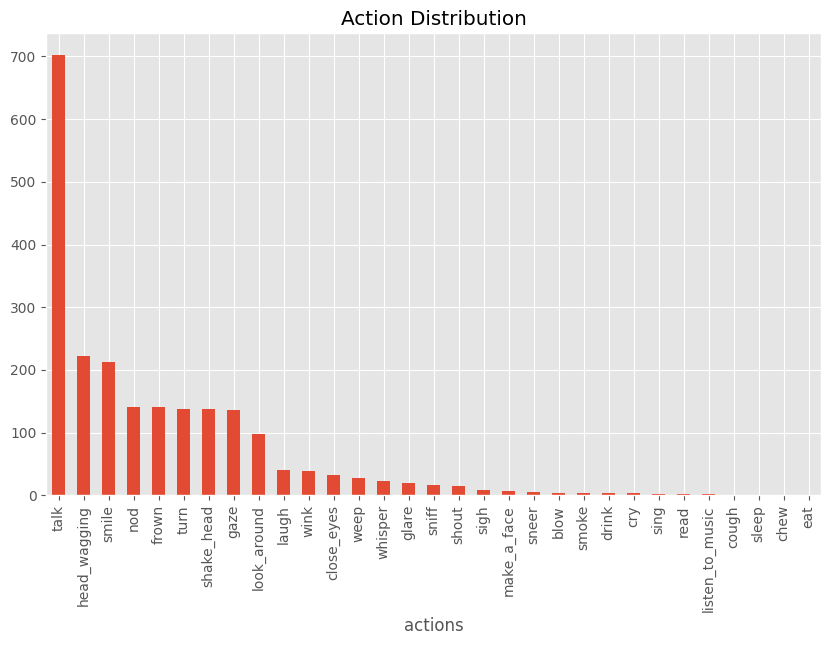


--- Video Length Statistics ---
count    702.000000
mean      16.721311
std        3.718889
min       10.000000
25%       12.800000
50%       19.335000
75%       19.980000
max       20.000000


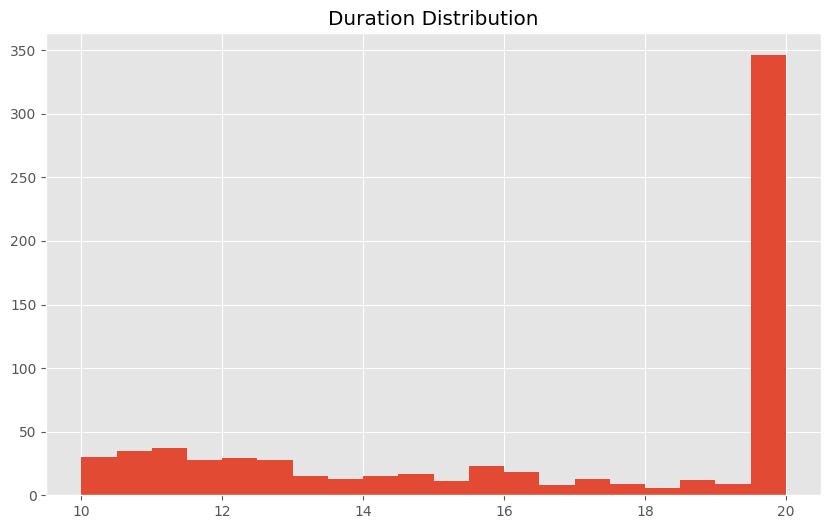

In [158]:
import pandas as pd
import matplotlib.pyplot as plt

# The analysis runs from the NEW metadata file
METADATA_CSV_PATH = 'final_dataset_metadata.csv'

try:
    df = pd.read_csv(METADATA_CSV_PATH)

    # --- Action Analysis ---
    all_actions = df['actions'].str.split(';').explode()
    action_counts = all_actions.value_counts()
    plt.figure(figsize=(10,6)); action_counts.plot(kind='bar'); plt.title('Action Distribution'); plt.show()


    # --- Duration Analysis ---
    duration_series = df['duration_sec']
    print("\n--- Video Length Statistics ---")
    print(duration_series.describe().to_string())
    # (Plotting code is the same...)
    plt.figure(figsize=(10,6)); plt.hist(duration_series, bins=20); plt.title('Duration Distribution'); plt.show()

except FileNotFoundError:
    print(f"Analysis failed: {METADATA_CSV_PATH} not found.")

In [149]:
import os

folder_path = '/content/sample_raw'
total_size = 0
total_files = 0

for dirpath, dirnames, filenames in os.walk(folder_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)
        total_files += 1

print(f"Total files in {folder_path}: {total_files}")
print(f"Total size of files in {folder_path}: {total_size / (1024*1024):.2f} MB")

Total files in /content/sample_raw: 2563
Total size of files in /content/sample_raw: 14042.76 MB


In [150]:
import os

folder_path = '/content/videos_dataset'
total_size = 0
total_files = 0

for dirpath, dirnames, filenames in os.walk(folder_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)
        total_files += 1

print(f"Total files in {folder_path}: {total_files}")
print(f"Total size of files in {folder_path}: {total_size / (1024*1024):.2f} MB")

Total files in /content/videos_dataset: 702
Total size of files in /content/videos_dataset: 314.30 MB


In [151]:
import os

folder_path = '/content/audios_dataset'
total_size = 0
total_files = 0

for dirpath, dirnames, filenames in os.walk(folder_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)
        total_files += 1

print(f"Total files in {folder_path}: {total_files}")
print(f"Total size of files in {folder_path}: {total_size / (1024*1024):.2f} MB")

Total files in /content/audios_dataset: 702
Total size of files in /content/audios_dataset: 925.00 MB


In [152]:
!zip -r videos_dataset.zip /content/videos_dataset

from google.colab import files
files.download('videos_dataset.zip')

  adding: content/videos_dataset/ (stored 0%)
  adding: content/videos_dataset/I9eKxEuHyYc_0.mp4 (deflated 4%)
  adding: content/videos_dataset/d85sc7BbmnA_0.mp4 (deflated 2%)
  adding: content/videos_dataset/qWb5_LSlsfM_6.mp4 (deflated 5%)
  adding: content/videos_dataset/EdDqhn43ZYQ_0.mp4 (deflated 2%)
  adding: content/videos_dataset/agYpqGEKNvQ_2.mp4 (deflated 3%)
  adding: content/videos_dataset/ljrdxgsfdug_5.mp4 (deflated 4%)
  adding: content/videos_dataset/Xz4BfAQMZZY_0.mp4 (deflated 2%)
  adding: content/videos_dataset/5ttoICpH0Vc_6.mp4 (deflated 3%)
  adding: content/videos_dataset/f2mHQzFNS9w_2.mp4 (deflated 2%)
  adding: content/videos_dataset/f0Hyj-aUrLo_11.mp4 (deflated 2%)
  adding: content/videos_dataset/DwbAW8G-57A_10.mp4 (deflated 2%)
  adding: content/videos_dataset/PFBrK7pbqCU_6.mp4 (deflated 2%)
  adding: content/videos_dataset/3AM5XP9t_f4_1.mp4 (deflated 2%)
  adding: content/videos_dataset/vehW_4wGUqM_0.mp4 (deflated 2%)
  adding: content/videos_dataset/Mgh_pqpSb

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [153]:
!zip -r audios_dataset.zip /content/audios_dataset

from google.colab import files
files.download('audios_dataset.zip')

  adding: content/audios_dataset/ (stored 0%)
  adding: content/audios_dataset/-QJsljIDKkk_0.wav (deflated 43%)
  adding: content/audios_dataset/3MmmG47ccSs_3.wav (deflated 29%)
  adding: content/audios_dataset/_zCEPgcZfYo_6.wav (deflated 8%)
  adding: content/audios_dataset/0t29L_75rV8_5.wav (deflated 11%)
  adding: content/audios_dataset/h5f5GgqVWes_0.wav (deflated 19%)
  adding: content/audios_dataset/U8PnHiRRg-s_6.wav (deflated 7%)
  adding: content/audios_dataset/1EHo4n1ppTE_5.wav (deflated 20%)
  adding: content/audios_dataset/_EpizUY_las_1.wav (deflated 34%)
  adding: content/audios_dataset/gHOBqLswFGE_1.wav (deflated 10%)
  adding: content/audios_dataset/C7LD5_tP33g_1.wav (deflated 18%)
  adding: content/audios_dataset/S866tTwzUIY_0.wav (deflated 24%)
  adding: content/audios_dataset/l17e0M4TTBA_5.wav (deflated 25%)
  adding: content/audios_dataset/B3Ej5iUVch0_1.wav (deflated 25%)
  adding: content/audios_dataset/6NLOGHyt5h4_4.wav (deflated 36%)
  adding: content/audios_dataset

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [154]:
from google.colab import files
files.download('final_dataset_metadata.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>